# **Day 6: Exploratory Data Analysis (EDA)**
*Module 1 - Foundations and Tools*

**EDA** is the detective work done **before** modelling. Its goals: understand the data, find quality problems, form hypotheses and choose models and features. Skipping EDA is the most common cause of silently wrong models.

We use a realistic **synthetic customer-churn dataset**, a standard business ML problem.

> Exploratory Data Analysis (EDA) means looking carefully at the data before modelling: its size, types, missing values, distributions, outliers and relationships. EDA prevents most beginner mistakes.
>
> *Example:* If 5% of the "forest" samples have NDVI below 0.1, EDA reveals them before training. They are probably label errors or cloudy pixels, not real forest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(6)
n = 3000
tenure = rng.integers(1, 72, n)
monthly = rng.normal(70, 25, n).clip(15, 150).round(2)
contract = rng.choice(["month-to-month", "one-year", "two-year"], n, p=[0.55, 0.25, 0.20])
support_calls = rng.poisson(1.5, n)
age = rng.normal(45, 14, n).clip(18, 90).round()
logit = (-1.0 - 0.04 * tenure + 0.02 * monthly + 0.45 * support_calls
         + np.select([contract == "one-year", contract == "two-year"], [-1.0, -2.0], 0))
churn = rng.random(n) < 1 / (1 + np.exp(-logit))

df = pd.DataFrame({"customer_id": np.arange(n), "age": age, "tenure_months": tenure,
                   "monthly_charge": monthly, "total_charge": (tenure * monthly * rng.normal(1, 0.03, n)).round(2),
                   "contract": contract, "support_calls": support_calls,
                   "region": rng.choice(["north", "south", "east", "west"], n),
                   "churn": churn.astype(int)})
df.loc[rng.choice(n, 150, replace=False), "age"] = np.nan
df.loc[rng.choice(n, 12, replace=False), "monthly_charge"] = -1          # sentinel / error values
df.loc[rng.choice(n, 40, replace=False), "total_charge"] = np.nan
df["cancel_reason_code"] = np.where(df.churn == 1, rng.integers(1, 6, n), 0)   # a LEAKY column!
df.head()

,customer_id,age,tenure_months,monthly_charge,total_charge,contract,support_calls,region,churn,cancel_reason_code
0,0,33.0,32,33.34,1083.53,month-to-month,1,east,1,3
1,1,39.0,39,96.95,3990.75,one-year,1,east,0,0
2,2,18.0,37,71.21,2567.08,month-to-month,0,west,0,0
3,3,38.0,25,66.66,1646.22,month-to-month,1,west,1,3
4,4,56.0,68,150.00,9514.52,month-to-month,2,north,1,4


## **Step 1: Structure**

In [2]:
print("Shape:", df.shape)
print(df.dtypes)
print("\nUnique values per column:\n", df.nunique())

Shape: (3000, 10)
customer_id             int64
age                   float64
tenure_months           int64
monthly_charge        float64
total_charge          float64
contract                  str
support_calls           int64
region                    str
churn                   int64
cancel_reason_code      int64
dtype: object

Unique values per column:
 customer_id           3000
age                     70
tenure_months           71
monthly_charge        2505
total_charge          2953
contract                 3
support_calls            8
region                   4
churn                    2
cancel_reason_code       6
dtype: int64


`customer_id` has a unique value per row: an **identifier**, never a feature. `region` and `contract` are **categorical**.

## **Step 2: Data Quality**

In [3]:
quality = pd.DataFrame({"missing": df.isna().sum(), "missing_%": (df.isna().mean() * 100).round(1),
                        "min": df.min(numeric_only=True), "max": df.max(numeric_only=True)})
print(quality)
print("\nDuplicated rows:", df.duplicated().sum())
print("Impossible values (monthly_charge < 0):", (df.monthly_charge < 0).sum())

                    missing  missing_%    min      max
age                     150        5.0  18.00    90.00
cancel_reason_code        0        0.0   0.00     5.00
churn                     0        0.0   0.00     1.00
contract                  0        0.0    NaN      NaN
customer_id               0        0.0   0.00  2999.00
monthly_charge            0        0.0  -1.00   150.00
region                    0        0.0    NaN      NaN
support_calls             0        0.0   0.00     7.00
tenure_months             0        0.0   1.00    71.00
total_charge             40        1.3  14.94  9514.52

Duplicated rows: 0
Impossible values (monthly_charge < 0): 12


`monthly_charge = -1` is a **sentinel** for "unknown". Treat it as missing, never as a number.

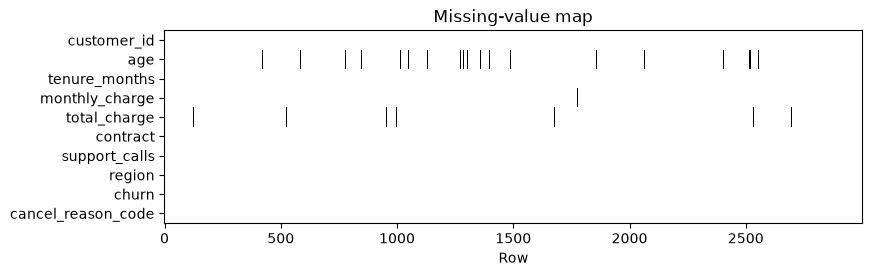

In [4]:
df["monthly_charge"] = df.monthly_charge.where(df.monthly_charge >= 0)

# Missing-value map: rows x columns (dark = missing). Patterns show whether values are missing together.
plt.figure(figsize=(9, 2.5))
plt.imshow(df.isna().T.values, aspect="auto", cmap="gray_r", interpolation="nearest")
plt.yticks(range(df.shape[1]), df.columns); plt.xlabel("Row"); plt.title("Missing-value map")
plt.show()

## **Step 3: Univariate Analysis**

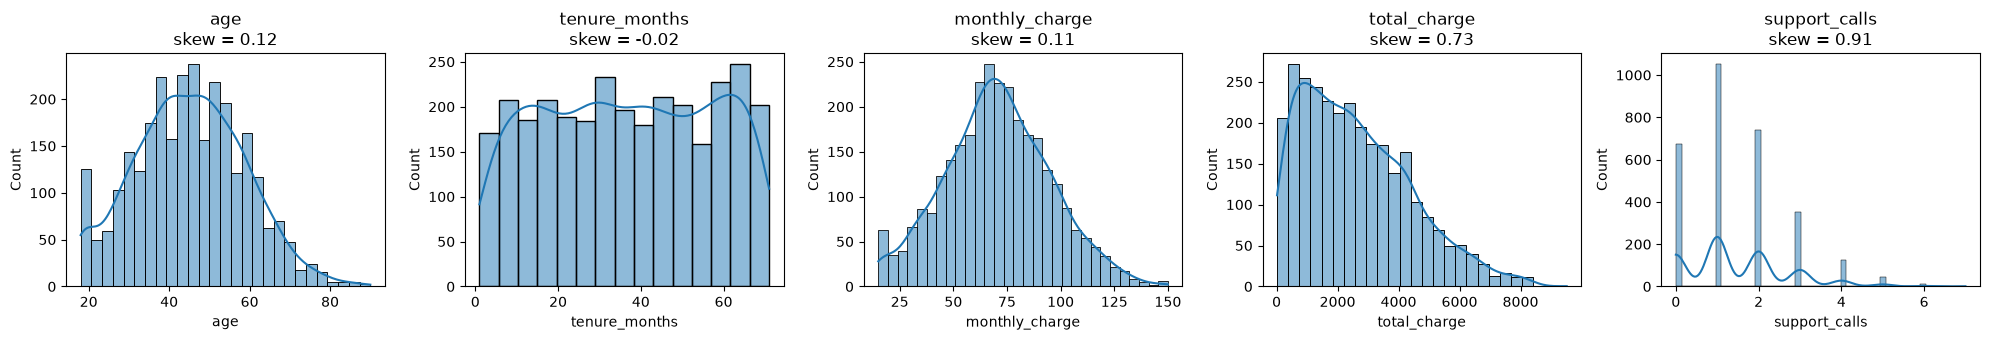

In [5]:
num_cols = ["age", "tenure_months", "monthly_charge", "total_charge", "support_calls"]
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c].dropna(), ax=ax, kde=True)
    ax.set_title(f"{c}\nskew = {df[c].skew():.2f}")
plt.tight_layout(); plt.show()

- **Skewness** > 1 (e.g. `total_charge`) suggests a log transform for linear models (Day 18).
- `support_calls` is a **count** (Poisson-like).

### Detecting outliers with the IQR rule

In [6]:
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

for c in num_cols:
    print(f"{c:<16} outliers: {iqr_outliers(df[c].dropna()).sum()}")

age              outliers: 10
tenure_months    outliers: 0
monthly_charge   outliers: 13
total_charge     outliers: 23
support_calls    outliers: 184


## **Step 4: Target Analysis**

Churn rate: 32.8%  ->  a model that always predicts 'no churn' already gets 67.2% accuracy!


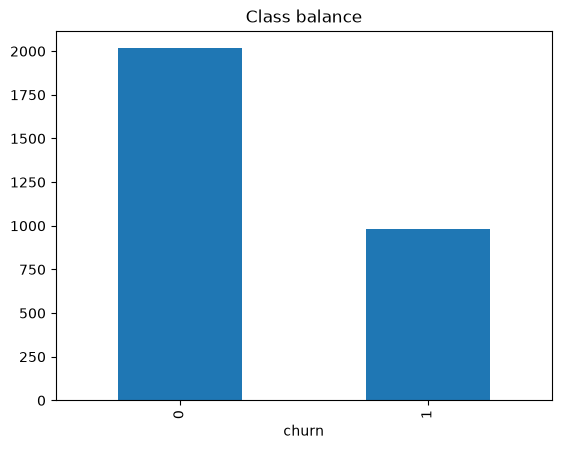

In [7]:
rate = df.churn.mean()
print(f"Churn rate: {rate:.1%}  ->  a model that always predicts 'no churn' already gets {1 - rate:.1%} accuracy!")
df.churn.value_counts().plot.bar(title="Class balance"); plt.show()

With imbalanced classes, accuracy is misleading. Use precision, recall, F1, ROC-AUC (Day 28) and imbalance methods (Day 21).

## **Step 5: Feature vs Target**

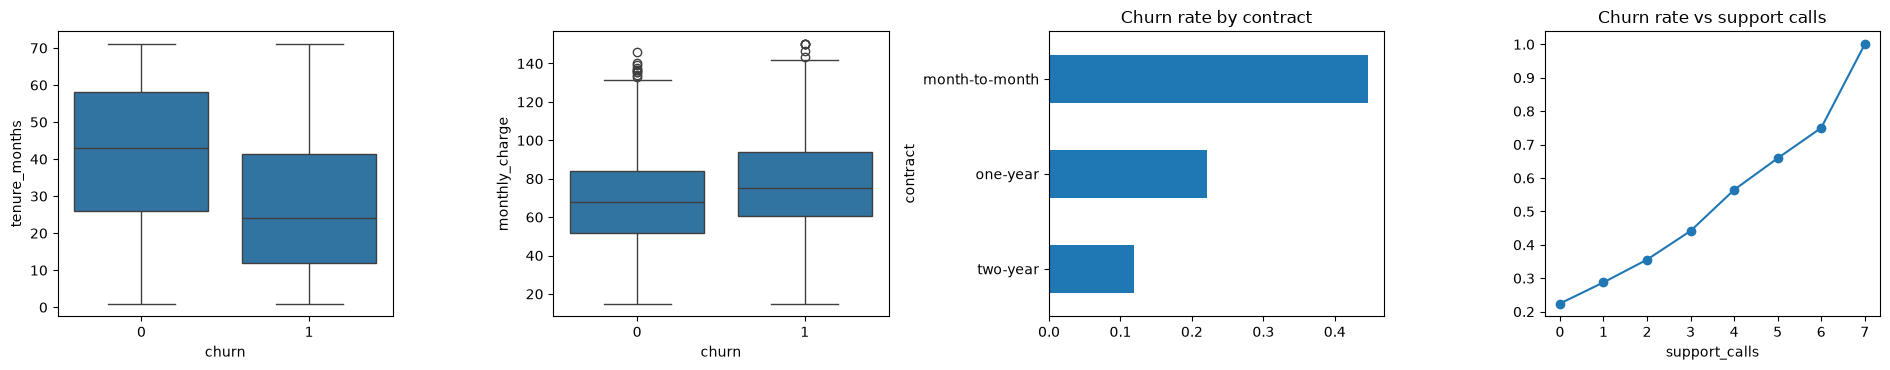

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
sns.boxplot(data=df, x="churn", y="tenure_months", ax=axes[0])
sns.boxplot(data=df, x="churn", y="monthly_charge", ax=axes[1])
df.groupby("contract").churn.mean().sort_values().plot.barh(ax=axes[2], title="Churn rate by contract")
df.groupby("support_calls").churn.mean().plot(marker="o", ax=axes[3], title="Churn rate vs support calls")
plt.tight_layout(); plt.show()

Hypotheses for modelling: short tenure, high charges, month-to-month contracts and many support calls increase churn.

## **Step 6: Correlations and Multicollinearity**

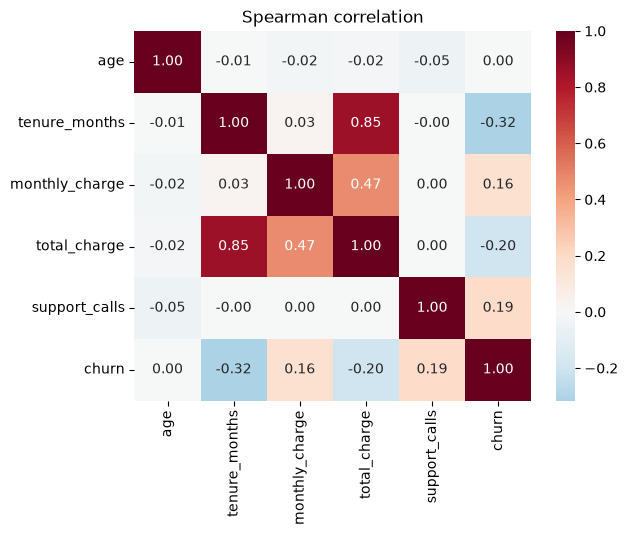

In [9]:
corr = df[num_cols + ["churn"]].corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0); plt.title("Spearman correlation"); plt.show()

`total_charge` is almost `tenure x monthly_charge`. Highly correlated features (|r| > 0.8) make linear-model coefficients unstable (Day 22, VIF) and split importance in tree models (Day 44).

## **Step 7: Leakage and Sanity Checks**
**Leakage** = a feature that contains information about the target that would **not be available at prediction time**. Leaky models look excellent in the notebook and fail in production.

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

single = {}
for c in ["tenure_months", "support_calls", "cancel_reason_code", "customer_id"]:
    single[c] = cross_val_score(DecisionTreeClassifier(max_depth=3), df[[c]].fillna(-1), df.churn, cv=5, scoring="roc_auc").mean()
print(pd.Series(single, name="ROC-AUC using one feature").round(3))

tenure_months         0.685
support_calls         0.613
cancel_reason_code    1.000
customer_id           0.501
Name: ROC-AUC using one feature, dtype: float64


`cancel_reason_code` alone gives AUC = 1.0: it is only filled in **after** a customer has churned. A single feature that predicts the target perfectly is almost always leakage. Remove it.

# **Part 2: Going Deeper - Automated and Statistical EDA**

### A reusable EDA report function

In [11]:
def eda_report(data: pd.DataFrame, target: str):
    rows = []
    for c in data.columns.drop(target):
        s = data[c]
        row = {"feature": c, "dtype": str(s.dtype), "missing_%": round(s.isna().mean() * 100, 1), "n_unique": s.nunique()}
        if pd.api.types.is_numeric_dtype(s):
            row.update(skew=round(s.skew(), 2), corr_target=round(s.corr(data[target], method="spearman"), 3))
        rows.append(row)
    rep = pd.DataFrame(rows).set_index("feature")
    rep["flag"] = np.select([rep.n_unique == len(data), rep.corr_target.abs() > 0.9, rep["missing_%"] > 30],
                            ["ID-like", "possible leakage", "many missing"], "")
    return rep

eda_report(df, "churn")

,dtype,missing_%,n_unique,skew,corr_target,flag
feature,,,,,,
customer_id,int64,0.0,3000,0.00,-0.013,ID-like
age,float64,5.0,70,0.12,0.000,
tenure_months,int64,0.0,71,-0.02,-0.316,
monthly_charge,float64,0.4,2504,0.11,0.159,
total_charge,float64,1.3,2953,0.73,-0.197,
contract,str,0.0,3,NaN,NaN,
support_calls,int64,0.0,8,0.91,0.191,
region,str,0.0,4,NaN,NaN,
cancel_reason_code,int64,0.0,6,1.40,0.975,possible leakage


### Mutual information: non-linear dependence
Correlation only detects **monotonic** relationships. **Mutual information** (Day 12) detects any dependence.

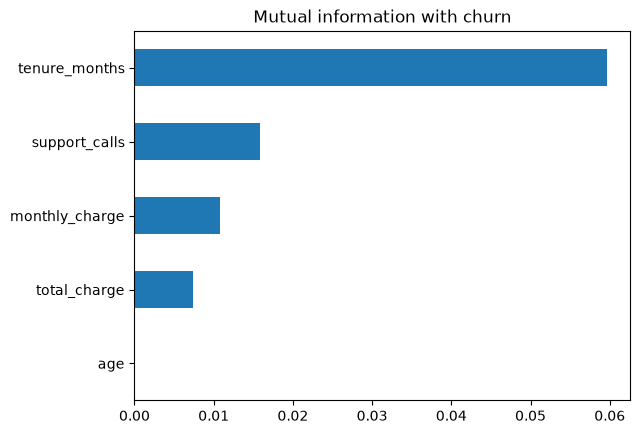

In [12]:
from sklearn.feature_selection import mutual_info_classif
X_mi = df[num_cols].fillna(df[num_cols].median())
mi = pd.Series(mutual_info_classif(X_mi, df.churn, random_state=0), index=num_cols).sort_values()
mi.plot.barh(title="Mutual information with churn"); plt.show()

### Are the distributions different between groups? (a first hypothesis test)

In [13]:
from scipy import stats
a = df.loc[df.churn == 1, "tenure_months"]; b = df.loc[df.churn == 0, "tenure_months"]
u, p = stats.mannwhitneyu(a, b)
print(f"Median tenure: churn={a.median():.0f}, stay={b.median():.0f} | Mann-Whitney p = {p:.2e}")

Median tenure: churn=24, stay=43 | Mann-Whitney p = 6.34e-67


## **Practice Problems**
1. Is the churn rate different by `region`? Make a bar chart. Is `region` likely useful?
2. Create `charge_per_month_check = total_charge / tenure_months` and compare it with `monthly_charge`. What do we learn?
3. List the final columns we would give to a model and explain why each excluded column is excluded.

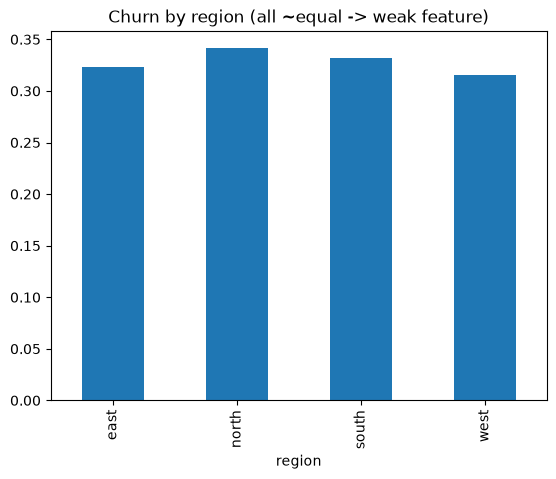

Correlation with monthly_charge: 0.996 -> redundant feature
Keep   : ['age', 'tenure_months', 'monthly_charge', 'contract', 'support_calls', 'region']
Exclude: customer_id (identifier), cancel_reason_code (leakage), total_charge (redundant)


In [14]:
# Solution 1
df.groupby("region").churn.mean().plot.bar(title="Churn by region (all ~equal -> weak feature)"); plt.show()
# Solution 2
chk = df.total_charge / df.tenure_months
print("Correlation with monthly_charge:", round(chk.corr(df.monthly_charge), 3), "-> redundant feature")
# Solution 3
print("Keep   :", ["age", "tenure_months", "monthly_charge", "contract", "support_calls", "region"])
print("Exclude: customer_id (identifier), cancel_reason_code (leakage), total_charge (redundant)")

## **Key References**
- Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data*, 6(4), 1-21.
- Kapoor, S., & Narayanan, A. (2023). Leakage and the reproducibility crisis in machine-learning-based science. *Patterns*, 4(9), 100804.